In [ ]:
import json
import ssl
import urllib.parse
import urllib.request

import certifi

params = urllib.parse.urlencode(
    {
        "start": "1",
        "limit": "15", # Number of cryptocurrencies to return
        "convert": "USD",
    }
)

request = urllib.request.Request(
    f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
    headers={
        "Accept": "application/json",
        "X-CMC_PRO_API_KEY": "75c74e39420443718582207851d06134",
    },
)

context = ssl.create_default_context(cafile=certifi.where())

with urllib.request.urlopen(request, context=context) as response:
    data = json.load(response)

print(data)

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20025871, 'total_supply': 20025871, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12624, 'cmc_rank': 1, 'last_updated': '2026-05-07T09:00:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1626167173577.49, 'quote': {'USD': {'price': 81203.31812671186, 'volume_24h': 39674727277.978455, 'cex_volume_24h': 39619374760.14601, 'dex_volume_24h': 55352517.83244054, 'volume_change_24h': -1.2553, 'percent_change_1h': -0.38595786, 'percent_change_24h': -0.89358488, 'percent_change_7d': 6.79352031, 'percent_change_30d': 17.78496593, 'percent_change_60d': 20.25183179, 'percent_change_90d': 25.15693181, 'market_cap': 1626167173577.4934, 'market_cap_dominance': 60.3749, 'fully_diluted_market_cap': 1705269680660.95, 'tvl': None, 'last_updated': '202

【结论】拉取出的数据是JSON格式，不方便观看，需要标准化Normalize.
【注意】输出数据是字典格式key-value pairs，顶层有一个键key "data"，其值value是一个列表。列表中的每个元素是一个字典。探索 JSON 数据结构的关键是 逐层打印 和 格式化输出Normalize，结合 Pandas 的 json_normalize 或调试工具，可以快速理解复杂的嵌套结构。

In [2]:
type(data)

dict

In [ ]:
import pandas as pd

pd.json_normalize(data["data"])

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,...,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address
0,1,Bitcoin,BTC,bitcoin,False,2.002587e+07,2.002587e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12624,...,1.626167e+12,60.3749,1.705270e+12,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN
1,1027,Ethereum,ETH,ethereum,True,1.206871e+08,1.206871e+08,NaN,2015-08-07T00:00:00.000Z,11926,...,2.815946e+11,10.4548,2.815946e+11,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN
2,825,Tether USDt,USDT,tether,True,1.896511e+11,1.942035e+11,NaN,2015-02-25T00:00:00.000Z,180652,...,1.895991e+11,7.0370,1.941502e+11,None,2026-05-07T09:00:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7
3,1839,BNB,BNB,bnb,False,1.347858e+08,1.347858e+08,1.347858e+08,2017-07-25T00:00:00.000Z,3218,...,8.770294e+10,3.2562,8.770294e+10,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN
4,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1830,...,8.751978e+10,3.2494,1.416264e+11,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN
5,3408,USDC,USDC,usd-coin,False,7.828862e+10,7.828862e+10,NaN,2018-10-08T00:00:00.000Z,39298,...,7.826806e+10,2.9066,7.826806e+10,None,2026-05-07T09:00:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48
6,5426,Solana,SOL,solana,True,5.770826e+08,6.258324e+08,NaN,2020-04-10T00:00:00.000Z,1126,...,5.167456e+10,1.9179,5.603984e+10,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN
7,1958,TRON,TRX,tron,True,9.479346e+10,9.479346e+10,NaN,2017-09-13T00:00:00.000Z,1338,...,3.270923e+10,1.2144,3.270923e+10,None,2026-05-07T09:01:00.000Z,NaN,NaN,NaN,NaN,NaN
8,74,Dogecoin,DOGE,dogecoin,True,1.698488e+11,1.698488e+11,NaN,2013-12-15T00:00:00.000Z,1439,...,1.894208e+10,0.7033,1.894208e+10,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN
9,32196,Hyperliquid,HYPE,hyperliquid,False,2.549854e+08,9.552602e+08,9.616715e+08,2024-07-15T10:14:50.000Z,259,...,1.093123e+10,0.4058,4.122687e+10,None,2026-05-07T09:00:00.000Z,32196.0,hyperliquid,Hyperliquid,HYPE,0x0d01dc56dcaaca66ad901c959b4011ec


调取网站中最新更新时间，以首行item的最新更新时间为例

In [4]:
pd.to_datetime(data["data"][0]["quote"]["USD"]["last_updated"])

Timestamp('2026-05-07 09:00:00+0000', tz='UTC')

【结论】更新时间为：0507 上午九点，timezone 时区为UTC

添加用户调取时间列"timestamp"

In [5]:
# 创建dataframe来承接标准化后的数据集，然后添加一个新的列来记录当前的时间戳

df = pd.json_normalize(data["data"])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,...,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.002587e+07,2.002587e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12624,...,60.3749,1.705270e+12,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 17:37:50.466081
1,1027,Ethereum,ETH,ethereum,True,1.206871e+08,1.206871e+08,NaN,2015-08-07T00:00:00.000Z,11926,...,10.4548,2.815946e+11,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 17:37:50.466081
2,825,Tether USDt,USDT,tether,True,1.896511e+11,1.942035e+11,NaN,2015-02-25T00:00:00.000Z,180652,...,7.0370,1.941502e+11,None,2026-05-07T09:00:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-07 17:37:50.466081
3,1839,BNB,BNB,bnb,False,1.347858e+08,1.347858e+08,1.347858e+08,2017-07-25T00:00:00.000Z,3218,...,3.2562,8.770294e+10,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 17:37:50.466081
4,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1830,...,3.2494,1.416264e+11,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 17:37:50.466081
5,3408,USDC,USDC,usd-coin,False,7.828862e+10,7.828862e+10,NaN,2018-10-08T00:00:00.000Z,39298,...,2.9066,7.826806e+10,None,2026-05-07T09:00:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-07 17:37:50.466081
6,5426,Solana,SOL,solana,True,5.770826e+08,6.258324e+08,NaN,2020-04-10T00:00:00.000Z,1126,...,1.9179,5.603984e+10,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 17:37:50.466081
7,1958,TRON,TRX,tron,True,9.479346e+10,9.479346e+10,NaN,2017-09-13T00:00:00.000Z,1338,...,1.2144,3.270923e+10,None,2026-05-07T09:01:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 17:37:50.466081
8,74,Dogecoin,DOGE,dogecoin,True,1.698488e+11,1.698488e+11,NaN,2013-12-15T00:00:00.000Z,1439,...,0.7033,1.894208e+10,None,2026-05-07T09:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 17:37:50.466081
9,32196,Hyperliquid,HYPE,hyperliquid,False,2.549854e+08,9.552602e+08,9.616715e+08,2024-07-15T10:14:50.000Z,259,...,0.4058,4.122687e+10,None,2026-05-07T09:00:00.000Z,32196.0,hyperliquid,Hyperliquid,HYPE,0x0d01dc56dcaaca66ad901c959b4011ec,2026-05-07 17:37:50.466081


自动化流程

In [63]:
import os
import json
import ssl
import urllib.parse
import urllib.request
import pandas as pd
import certifi
from time import sleep

loop_number = 1 # 初始化循环序号，批次追踪（Batch Tracking）

# 1. 环境初始化：确保每次重新运行此单元格时，数据都是“干净”的
# 删除现有的 CSV 文件（如果存在），以便重新创建并写入新的数据
csv_file = 'crypto_data.csv'
if os.path.exists('crypto_data.csv'):
    os.remove('crypto_data.csv') # 删除 CSV 文件，以便重新创建并写入新的数据
    print(f"--- 已清理旧文件 {csv_file}，环境初始化完成 ---")

# 2. 定义函数：通过参数传递 loop_id
def api_runner(loop_id):

    params = urllib.parse.urlencode(
        {
            "start": "1",
            "limit": "15", # Number of cryptocurrencies to return
            "convert": "USD",
        }
    )

    request = urllib.request.Request(
        f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
        headers={
            "Accept": "application/json",
            "X-CMC_PRO_API_KEY": "75c74e39420443718582207851d06134",
        },
    )

    context = ssl.create_default_context(cafile=certifi.where())

    # 加入异常处理，防止网络波动中断次循环
    try:
        with urllib.request.urlopen(request, context=context) as response:
            data = json.load(response)

        # 数据标准化
        df2 = pd.json_normalize(data["data"]) # 标准化 JSON 数据并创建一个新的 DataFrame
        
        # 3. 赋值与排序逻辑整合
        df2['timestamp'] = pd.Timestamp.now() # 添加一个新的列来记录当前的时间戳，方便后续做时间序列分析（Time Series Analysis）
        #df2['timestamp'] = pd.to_datetime('now')
        df2['loop_id'] = loop_id
        
        # 一次性排好列顺序：loop_id -> timestamp -> 其他
        ranked_cols = ['loop_id', 'timestamp']
        other_cols = [col for col in df2.columns if col not in ranked_cols]
        df2 = df2[ranked_cols + other_cols] # 重新排列列的顺序，使 loop_id 和 timestamp 列排在前面，其他列跟在后面
    
        # 4. 写入 CSV 文件
        if not os.path.exists(csv_file): # 如果csv文件不存在，则创建并写入数据；如果存在，则追加数据；在代码中没有明确指定 CSV 文件的路径，那么文件会被创建在 当前工作目录 下。
            df2.to_csv(csv_file, header=True, index=False) # header='column_names' 表示在写入 CSV 文件时包含列名，index=False 表示不写入行索引；
        else:
            df2.to_csv(csv_file, mode='a', header=False, index=False) # mode='a' 表示以追加模式写入数据
        
        # 输出日志：打印当前批次的抓取成功信息和时间戳，方便追踪每次抓取的时间点
        print(f"Batch {loop_id} 抓取成功 | 时间: {df2['timestamp'].iloc[0]}")

    except Exception as e:
        print(f"Batch {loop_id} 抓取失败: {e}")

In [64]:
# 执行入口
if __name__ == "__main__":
    try:
        for i in range(1, 301): # 运行 300 次
            api_runner(i)
            sleep(60) # 间隔 60 秒
            print(f"Iteration {i} completed. Sleeping for 60 seconds...")
        print("--- 300 次抓取任务全部完成 ---")
    except KeyboardInterrupt: # 捕获键盘中断（Ctrl+C）来手动停止抓取，在Jupyter Notebook是点按“方块”形状的图标
        print("手动停止抓取。数据已保存至 crypto_data.csv")
    except Exception as e:
        print(f"发生错误: {e}")

Batch 1 抓取成功 | 时间: 2026-05-07 20:07:08.487767
Iteration 1 completed. Sleeping for 60 seconds...
Batch 2 抓取成功 | 时间: 2026-05-07 20:08:09.670831
Iteration 2 completed. Sleeping for 60 seconds...
Batch 3 抓取成功 | 时间: 2026-05-07 20:09:10.733342
手动停止抓取。数据已保存至 crypto_data.csv


很多列的值是采用科学计数法，不方便观察，现在改为float

In [85]:
pd.set_option('display.max_columns', None) # 不折叠，显示所有列
#pd.set_option('display.float_format', '{:.5f}'.format) # 设置浮点数显示格式为5位小数
pd.set_option('display.float_format', lambda x: '%.5f' % x) # 设置浮点数显示格式为5位小数，使用 lambda 函数来格式化每个浮点数的显示方式

df = pd.read_csv('crypto_data.csv')
df.head()

,loop_id,timestamp,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address
0,1,2026-05-07 20:07:08.487767,1,Bitcoin,BTC,bitcoin,False,20025943.00000,20025943.00000,21000000.00000,2010-07-13T00:00:00.000Z,12626,1,2026-05-07T12:05:00.000Z,NaN,NaN,NaN,NaN,1621392477594.15991,"['mineable', 'pow', 'sha-256', 'store-of-value...",80964.60065,35542827184.72066,35490287721.35303,52539463.36763,-19.08770,0.02507,-1.69319,6.42377,18.39023,19.80856,22.08489,1621392477594.16211,60.44670,1700256613607.53003,NaN,2026-05-07T12:05:00.000Z,NaN,NaN,NaN,NaN,NaN
1,1,2026-05-07 20:07:08.487767,1027,Ethereum,ETH,ethereum,True,120687104.06368,120687104.06368,NaN,2015-08-07T00:00:00.000Z,11926,2,2026-05-07T12:05:00.000Z,NaN,NaN,NaN,NaN,281538719921.44000,"['pos', 'smart-contracts', 'ethereum-ecosystem...",2332.79870,21690941357.58501,21552739744.78706,138201612.79794,5.85810,0.14837,-3.09952,3.26801,11.67235,19.45732,21.24329,281538719921.43744,10.49600,281538719921.44000,NaN,2026-05-07T12:05:00.000Z,NaN,NaN,NaN,NaN,NaN
2,1,2026-05-07 20:07:08.487767,825,Tether USDt,USDT,tether,True,189651082316.74588,194203497624.11526,NaN,2015-02-25T00:00:00.000Z,180717,3,2026-05-07T12:04:00.000Z,NaN,NaN,NaN,NaN,194168744638.89999,"['stablecoin', 'asset-backed-stablecoin', 'usd...",0.99982,123562092916.84320,120556284267.10768,3005808649.73524,-14.96880,0.00593,-0.00032,0.02287,-0.00365,-0.01078,0.10451,189617143992.56583,7.06940,194168744638.89999,NaN,2026-05-07T12:04:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7
3,1,2026-05-07 20:07:08.487767,1839,BNB,BNB,bnb,False,134785800.16000,134785800.16000,134785800.16000,2017-07-25T00:00:00.000Z,3218,4,2026-05-07T12:05:00.000Z,NaN,NaN,NaN,NaN,87348796095.67999,"['marketplace', 'centralized-exchange', 'payme...",648.05637,2045824688.49757,2028131832.45025,17692856.04732,-6.87100,0.01794,-0.66666,5.27131,8.55726,4.43558,2.13802,87348796095.67839,3.25640,87348796095.67999,NaN,2026-05-07T12:05:00.000Z,NaN,NaN,NaN,NaN,NaN
4,1,2026-05-07 20:07:08.487767,52,XRP,XRP,xrp,False,61796225236.00000,99985670046.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1830,5,2026-05-07T12:05:00.000Z,NaN,NaN,NaN,NaN,141074615375.82999,"['medium-of-exchange', 'enterprise-solutions',...",1.41095,2389857779.34528,2388811491.44094,1046287.90434,-11.46810,0.00528,-2.72889,3.00932,7.98230,3.87990,3.45044,87191281539.00720,3.25060,141094834200.67001,NaN,2026-05-07T12:05:00.000Z,NaN,NaN,NaN,NaN,NaN


根据当前取出的数据，分组分析

【注意】Pandas 中只有两种数据格式，Series（最简单的序列，单行或单列，没有行列的概念），DataFrame（表格，有行列的概念）
- 要注意有些method的调用只能在 DataFrame 上使用，比如，.stack()是把表格的列堆叠在行上，如果在没有列概念的Series上使用，会出现 AttributeError

In [ ]:
# 1. 按照name列分组，计算quote.USD.price列的平均值，并重置索引

df3 = df.groupby('name', sort=False)['quote.USD.price'].mean().reset_index() # 按照name列分组聚合（格式变成Series），计算quote.USD.price 列的平均值，并.reset_index()重置索引（格式变回DataFrame)

df3 = df3.sort_values(by='quote.USD.price', ascending=False) # 按照quote.USD.price列进行降序排序

df3

,name,quote.USD.price
0,Bitcoin,80951.74882
1,Ethereum,2332.41071
3,BNB,648.12070
11,Zcash,574.17136
13,Bitcoin Cash,458.61518
14,Monero,415.34225
6,Solana,89.68562
9,Hyperliquid,42.80757
12,UNUS SED LEO,10.35036
4,XRP,1.41106


In [128]:
# 也可以在单元素上加双括号

df3 = df.groupby('name', sort=False)[['quote.USD.price']].mean().reset_index() # 按照name列分组聚合（格式变成Series），计算quote.USD.price 列的平均值，并.reset_index()重置索引（格式变回DataFrame)

df3 = df3.sort_values(by='quote.USD.price', ascending=False) # 按照quote.USD.price列进行降序排序

df3

,name,quote.USD.price
0,Bitcoin,80951.74882
1,Ethereum,2332.41071
3,BNB,648.12070
11,Zcash,574.17136
13,Bitcoin Cash,458.61518
14,Monero,415.34225
6,Solana,89.68562
9,Hyperliquid,42.80757
12,UNUS SED LEO,10.35036
4,XRP,1.41106


In [157]:
df4 = df.groupby('name', sort=False)[['quote.USD.price', 'quote.USD.volume_24h', 'quote.USD.cex_volume_24h', 'quote.USD.dex_volume_24h', 'quote.USD.percent_change_1h', 'quote.USD.percent_change_24h', 'quote.USD.percent_change_7d', 'quote.USD.percent_change_30d', 'quote.USD.percent_change_60d', 'quote.USD.percent_change_90d', 'quote.USD.market_cap', 'quote.USD.fully_diluted_market_cap']].mean() # 按照name列分组，计算多个列的平均值
df4

,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.fully_diluted_market_cap
name,,,,,,,,,,,,
Bitcoin,80951.74882,35536073200.59546,35484030458.91433,52042741.68112,-0.04339,-1.69107,6.37500,18.60238,19.86332,22.09691,1621135107620.23169,1699986725220.62329
Ethereum,2332.41071,21694016650.11485,21556116940.05014,137899710.06472,0.09927,-3.10697,3.22302,11.98162,19.51793,21.22453,281491893623.44904,281491893623.45001
Tether USDt,0.99981,123557238621.43303,120549784750.61565,3007453870.81715,0.00158,-0.00409,0.02068,-0.00684,-0.01019,0.11273,189615368770.00919,194166926803.61331
BNB,648.12070,2042903403.23493,2025213019.21530,17690384.01963,-0.00424,-0.63711,5.26533,8.59441,4.43869,2.21381,87357466760.89568,87357466760.89667
XRP,1.41106,2389065309.93386,2388019457.53150,1045852.40236,-0.03172,-2.68517,2.98932,8.02975,3.90034,3.60201,87198403896.96388,141106359755.71667
USDC,0.99982,45880551895.89309,43746638353.11716,2133913542.77592,-0.00212,0.01338,-0.00281,-0.00478,-0.01093,0.00081,78332653153.31326,78332653153.31334
Solana,89.68562,5055868880.92448,5055842705.34689,26175.57759,0.36572,-0.09002,8.01079,13.20501,8.20146,10.58451,51756001098.53683,56128154323.68667
TRON,0.34691,723266425.68875,723127812.28367,138613.40508,0.00431,1.22116,6.51213,10.36151,21.22942,28.92182,32884474471.10511,32884474493.80000
Dogecoin,0.11122,2071040386.61961,2069968474.28889,1071912.33072,0.09615,-4.58662,4.45471,22.88689,24.43845,19.16933,17142753631.49192,17142753631.49000


In [153]:
type(df4)

pandas.core.frame.DataFrame

In [154]:
df4 = df.groupby('name', sort=False)[['quote.USD.price', 'quote.USD.volume_24h', 'quote.USD.cex_volume_24h', 'quote.USD.dex_volume_24h', 'quote.USD.percent_change_1h', 'quote.USD.percent_change_24h', 'quote.USD.percent_change_7d', 'quote.USD.percent_change_30d', 'quote.USD.percent_change_60d', 'quote.USD.percent_change_90d', 'quote.USD.market_cap', 'quote.USD.fully_diluted_market_cap']].mean().reset_index() # 按照name列分组，计算多个列的平均值，并重置索引
df4 = df4.sort_values(by='quote.USD.price', ascending=False) # 按照quote.USD.price列进行降序排序
df4

,name,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.fully_diluted_market_cap
0,Bitcoin,80951.74882,35536073200.59546,35484030458.91433,52042741.68112,-0.04339,-1.69107,6.37500,18.60238,19.86332,22.09691,1621135107620.23169,1699986725220.62329
1,Ethereum,2332.41071,21694016650.11485,21556116940.05014,137899710.06472,0.09927,-3.10697,3.22302,11.98162,19.51793,21.22453,281491893623.44904,281491893623.45001
3,BNB,648.12070,2042903403.23493,2025213019.21530,17690384.01963,-0.00424,-0.63711,5.26533,8.59441,4.43869,2.21381,87357466760.89568,87357466760.89667
11,Zcash,574.17136,1150098832.94169,1133951046.66191,16147786.27977,0.38374,-0.09942,71.24728,116.12828,190.22191,153.41817,9567895617.53536,12057598662.55000
13,Bitcoin Cash,458.61518,236113370.29283,236095171.87507,18198.41776,-0.02183,-2.88670,3.12410,6.05245,2.18889,-2.66151,9186609563.21494,9630918817.68333
14,Monero,415.34225,195051516.09201,195051516.09201,0.00000,0.49773,-3.18531,10.07575,26.16157,20.73803,35.06011,7661712116.92893,7661712116.92667
6,Solana,89.68562,5055868880.92448,5055842705.34689,26175.57759,0.36572,-0.09002,8.01079,13.20501,8.20146,10.58451,51756001098.53683,56128154323.68667
9,Hyperliquid,42.80757,370407277.12694,302339672.14194,68067604.98499,0.09020,-4.14535,10.26513,17.51303,40.88449,26.84201,10915160186.37541,41166817588.90333
12,UNUS SED LEO,10.35036,427061.18896,427061.18896,0.00000,0.00326,0.02862,0.22209,2.24720,14.54486,51.87117,9529335769.27723,10197583237.38667
4,XRP,1.41106,2389065309.93386,2388019457.53150,1045852.40236,-0.03172,-2.68517,2.98932,8.02975,3.90034,3.60201,87198403896.96388,141106359755.71667


In [158]:
df4 = df4.stack()
df4

name                                            
Bitcoin       quote.USD.price                              80951.74882
              quote.USD.volume_24h                   35536073200.59546
              quote.USD.cex_volume_24h               35484030458.91433
              quote.USD.dex_volume_24h                  52042741.68112
              quote.USD.percent_change_1h                     -0.04339
              quote.USD.percent_change_24h                    -1.69107
              quote.USD.percent_change_7d                      6.37500
              quote.USD.percent_change_30d                    18.60238
              quote.USD.percent_change_60d                    19.86332
              quote.USD.percent_change_90d                    22.09691
              quote.USD.market_cap                 1621135107620.23169
              quote.USD.fully_diluted_market_cap   1699986725220.62329
Ethereum      quote.USD.price                               2332.41071
              quote.USD.volu

In [156]:
type(df4)

pandas.core.series.Series

【注意】
- .stack() 的动作是把列索引 (Columns) 压入到 行索引 (Index) 中，让DataFrame变成了一个多级索引序列Multiindex Series
- 在这里面crypto名字、指标名分别是一级、二级索引，但是真正的数值只有一列，所以他是个序列Series

In [166]:
df5 = df4.to_frame(name='values') # 将Series转换为DataFrame，并命名新列为'value'
df5

values
name                                                               
Bitcoin      quote.USD.price                            80951.74882
             quote.USD.volume_24h                 35536073200.59546
             quote.USD.cex_volume_24h             35484030458.91433
             quote.USD.dex_volume_24h                52042741.68112
             quote.USD.percent_change_1h                   -0.04339
             quote.USD.percent_change_24h                  -1.69107
             quote.USD.percent_change_7d                    6.37500
             quote.USD.percent_change_30d                  18.60238
             quote.USD.percent_change_60d                  19.86332
             quote.USD.percent_change_90d                  22.09691
             quote.USD.market_cap               1621135107620.23169
             quote.USD.fully_diluted_market_cap 1699986725220.62329
Ethereum     quote.USD.price                             2332.41071
             quote.USD.volume_24h                 21694016650.11485
             quote.USD.cex_volume_24h             21556116940.05014
             quote.USD.dex_volume_24h               137899710.06472
             quote.USD.percent_change_1h                    0.09927
             quote.USD.percent_change_24h                  -3.10697
             quote.USD.percent_change_7d                    3.22302
             quote.USD.percent_change_30d                  11.98162
             quote.USD.percent_change_60d                  19.51793
             quote.USD.percent_change_90d                  21.22453
             quote.USD.market_cap                281491893623.44904
             quote.USD.fully_diluted_market_cap  281491893623.45001
Tether USDt  quote.USD.price                                0.99981
             quote.USD.volume_24h                123557238621.43303
             quote.USD.cex_volume_24h            120549784750.61565
             quote.USD.dex_volume_24h              3007453870.81715
             quote.USD.percent_change_1h                    0.00158
             quote.USD.percent_change_24h                  -0.00409
             quote.USD.percent_change_7d                    0.02068
             quote.USD.percent_change_30d                  -0.00684
             quote.USD.percent_change_60d                  -0.01019
             quote.USD.percent_change_90d                   0.11273
             quote.USD.market_cap                189615368770.00919
             quote.USD.fully_diluted_market_cap  194166926803.61331
BNB          quote.USD.price                              648.12070
             quote.USD.volume_24h                  2042903403.23493
             quote.USD.cex_volume_24h              2025213019.21530
             quote.USD.dex_volume_24h                17690384.01963
             quote.USD.percent_change_1h                   -0.00424
             quote.USD.percent_change_24h                  -0.63711
             quote.USD.percent_change_7d                    5.26533
             quote.USD.percent_change_30d                   8.59441
             quote.USD.percent_change_60d                   4.43869
             quote.USD.percent_change_90d                   2.21381
             quote.USD.market_cap                 87357466760.89568
             quote.USD.fully_diluted_market_cap   87357466760.89667
XRP          quote.USD.price                                1.41106
             quote.USD.volume_24h                  2389065309.93386
             quote.USD.cex_volume_24h              2388019457.53150
             quote.USD.dex_volume_24h                 1045852.40236
             quote.USD.percent_change_1h                   -0.03172
             quote.USD.percent_change_24h                  -2.68517
             quote.USD.percent_change_7d                    2.98932
             quote.USD.percent_change_30d                   8.02975
             quote.USD.percent_change_60d                   3.90034
             quote.USD.percent_change_90d        

In [168]:
type(df5)

pandas.core.frame.DataFrame

In [171]:

df6 = df5.reset_index() # 重置索引，将原来的索引变成普通列
df6

,name,level_1,values
0,Bitcoin,quote.USD.price,80951.74882
1,Bitcoin,quote.USD.volume_24h,35536073200.59546
2,Bitcoin,quote.USD.cex_volume_24h,35484030458.91433
3,Bitcoin,quote.USD.dex_volume_24h,52042741.68112
4,Bitcoin,quote.USD.percent_change_1h,-0.04339
5,Bitcoin,quote.USD.percent_change_24h,-1.69107
6,Bitcoin,quote.USD.percent_change_7d,6.37500
7,Bitcoin,quote.USD.percent_change_30d,18.60238
8,Bitcoin,quote.USD.percent_change_60d,19.86332
9,Bitcoin,quote.USD.percent_change_90d,22.09691


In [173]:
df6 = df6.rename(columns={'name': 'names', 'level_1': 'metrics'}) # 重命名列，将原来的索引列重命名为'names'和'metris'
df6

,names,metrics,values
0,Bitcoin,quote.USD.price,80951.74882
1,Bitcoin,quote.USD.volume_24h,35536073200.59546
2,Bitcoin,quote.USD.cex_volume_24h,35484030458.91433
3,Bitcoin,quote.USD.dex_volume_24h,52042741.68112
4,Bitcoin,quote.USD.percent_change_1h,-0.04339
5,Bitcoin,quote.USD.percent_change_24h,-1.69107
6,Bitcoin,quote.USD.percent_change_7d,6.37500
7,Bitcoin,quote.USD.percent_change_30d,18.60238
8,Bitcoin,quote.USD.percent_change_60d,19.86332
9,Bitcoin,quote.USD.percent_change_90d,22.09691


# 研究percent change

In [189]:
df10 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h', 'quote.USD.percent_change_24h', 'quote.USD.percent_change_7d', 'quote.USD.percent_change_30d', 'quote.USD.percent_change_60d', 'quote.USD.percent_change_90d']].mean() # 按照name列分组，计算多个列的平均值，并重置索引
df10

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.04339,-1.69107,6.37500,18.60238,19.86332,22.09691
Ethereum,0.09927,-3.10697,3.22302,11.98162,19.51793,21.22453
Tether USDt,0.00158,-0.00409,0.02068,-0.00684,-0.01019,0.11273
BNB,-0.00424,-0.63711,5.26533,8.59441,4.43869,2.21381
XRP,-0.03172,-2.68517,2.98932,8.02975,3.90034,3.60201
USDC,-0.00212,0.01338,-0.00281,-0.00478,-0.01093,0.00081
Solana,0.36572,-0.09002,8.01079,13.20501,8.20146,10.58451
TRON,0.00431,1.22116,6.51213,10.36151,21.22942,28.92182
Dogecoin,0.09615,-4.58662,4.45471,22.88689,24.43845,19.16933


In [205]:
df11 = df10.stack().reset_index(name='values').rename(columns={'name': 'names', 'level_1': 'pct_change'}) # 将DataFrame进行堆叠（stack），重置索引，并重命名列
df11

,names,pct_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.04339
1,Bitcoin,quote.USD.percent_change_24h,-1.69107
2,Bitcoin,quote.USD.percent_change_7d,6.37500
3,Bitcoin,quote.USD.percent_change_30d,18.60238
4,Bitcoin,quote.USD.percent_change_60d,19.86332
5,Bitcoin,quote.USD.percent_change_90d,22.09691
6,Ethereum,quote.USD.percent_change_1h,0.09927
7,Ethereum,quote.USD.percent_change_24h,-3.10697
8,Ethereum,quote.USD.percent_change_7d,3.22302
9,Ethereum,quote.USD.percent_change_30d,11.98162


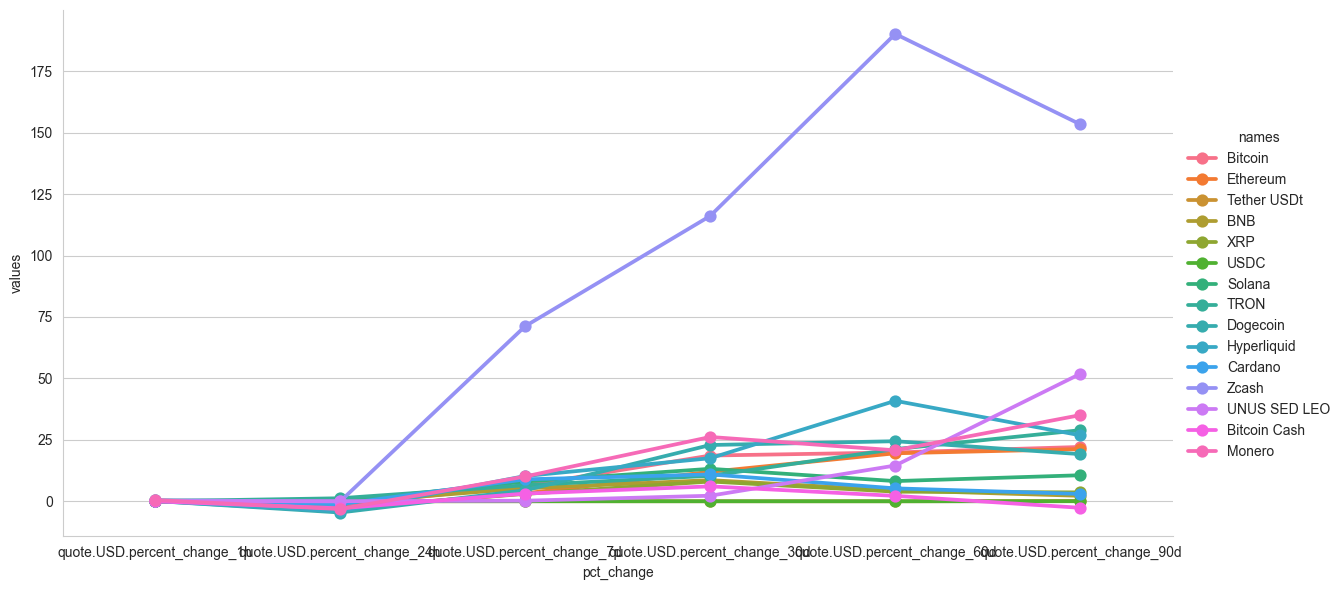

In [206]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置 Seaborn 的样式和调色板，以提升图表的美观度和可读性
sns.set_style('whitegrid') # 设置 Seaborn 的样式为白色网格
sns.set_palette('Set2') # 设置 Seaborn 的调色板为 Set2，提供一组柔和的颜色

# 创建一个分类图（catplot），以展示不同加密货币在不同时间段的百分比变化情况
sns.catplot(x='pct_change', y='values', hue='names', data=df11, kind='point', height=6, aspect=2) 

In [ ]:
df11['pct_change'] = df11['pct_change'].replace(['quote.USD.percent_change_24h'],['24h']) # 去掉列名中的前缀，保留时间段信息
df11

,names,pct_change,values
0,Bitcoin,1h,-0.04339
1,Bitcoin,24h,-1.69107
2,Bitcoin,7d,6.37500
3,Bitcoin,30d,18.60238
4,Bitcoin,60d,19.86332
5,Bitcoin,90d,22.09691
6,Ethereum,1h,0.09927
7,Ethereum,24h,-3.10697
8,Ethereum,7d,3.22302
9,Ethereum,30d,11.98162


# str访问器

In [213]:
type(df11['pct_change'].str)

pandas.core.strings.accessor.StringMethods

In [214]:
# str访问器是Pandas中用于处理字符串数据的一种工具，它提供了一系列方法来操作和处理字符串类型的数据。当我们在DataFrame中使用str访问器时，可以对特定列中的字符串数据进行各种操作，例如替换、提取、分割等。
# .str来获取特定列的值，是因为pct_change列中的值是字符串类型的，而不是数值类型的。str访问器提供了一系列字符串方法，可以对字符串进行操作和处理
# 我们使用str.replace()方法来替换字符串中的特定部分，以去掉列名中的前缀，保留时间段信息，使得图表中的标签更简洁和易读。
df11['pct_change'] = df11['pct_change'].str.replace('quote.USD.percent_change_', '') # 去掉列名中的前缀，保留时间段信息
df11

,names,pct_change,values
0,Bitcoin,1h,-0.04339
1,Bitcoin,24h,-1.69107
2,Bitcoin,7d,6.37500
3,Bitcoin,30d,18.60238
4,Bitcoin,60d,19.86332
5,Bitcoin,90d,22.09691
6,Ethereum,1h,0.09927
7,Ethereum,24h,-3.10697
8,Ethereum,7d,3.22302
9,Ethereum,30d,11.98162


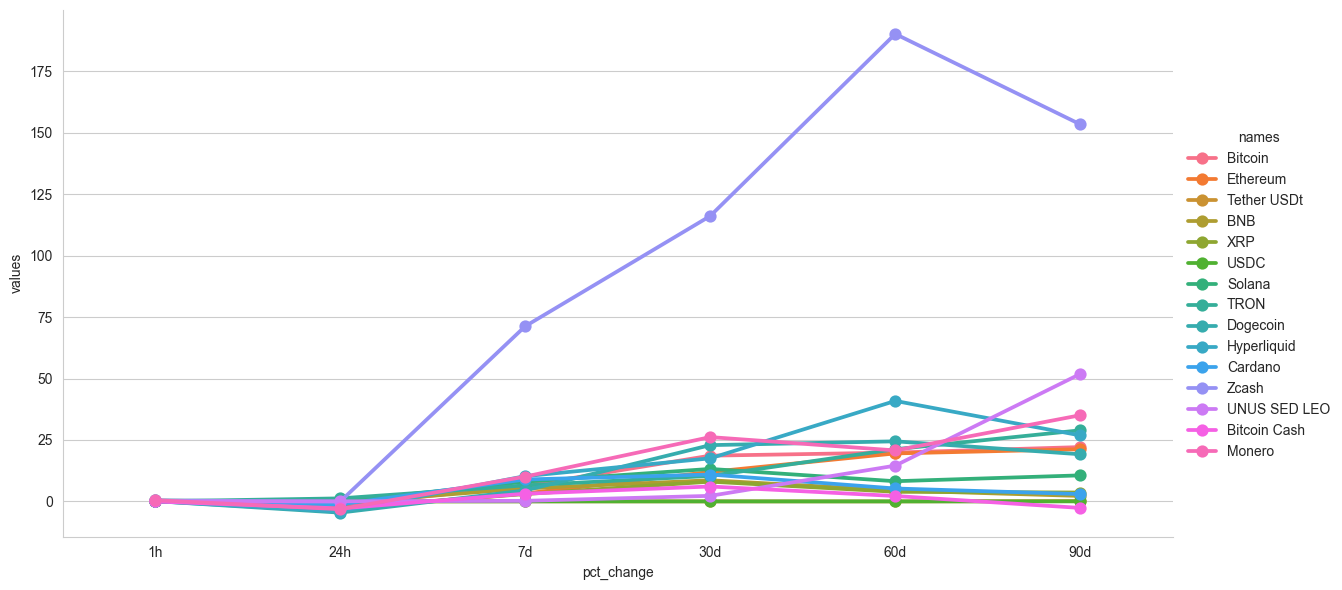

In [209]:
# 创建一个分类图（catplot），以展示不同加密货币在不同时间段的百分比变化情况
sns.catplot(x='pct_change', y='values', hue='names', data=df11, kind='point', height=6, aspect=2) 

In [212]:
df11['pct_change'].dtype

dtype('O')

在 Pandas 中，object 实际上就是存储字符串（string）的默认方式。
Pandas 是建立在 NumPy 之上的。NumPy 诞生时，为了处理长度不一的文本数据，定义了一种通用的 object 指针类型。
它在内存中存储的是数据的地址，而不是数据本身。长期以来，Pandas 沿用了这个设定。所以当你看到 dtype('O') 时，
它其实是在说：“这一列包含的是 Python 对象（通常是字符串）。”它不仅仅能装字符串，还能同时装下 None、列表、字典甚至是混合类型。
虽然它叫 object，但只要里面的内容是字符串，你依然可以使用 .str 访问器。

In [ ]:
# Time Series Analysis

df12 = df[['name', 'quote.USD.price', 'timestamp']] # 从原始 DataFrame 中选择特定的列，创建一个新的 DataFrame df12
df12 = df12.query('name == "Bitcoin" or name == "Ethereum"') # 使用 query 方法过滤数据，只保留 name 列中值为 "Bitcoin" 或 "Ethereum" 的行
df12

,name,quote.USD.price,timestamp
0,Bitcoin,80964.60065,2026-05-07 20:07:08.487767
1,Ethereum,2332.79870,2026-05-07 20:07:08.487767
15,Bitcoin,80962.25300,2026-05-07 20:08:09.670831
16,Ethereum,2332.80255,2026-05-07 20:08:09.670831
30,Bitcoin,80928.39281,2026-05-07 20:09:10.733342
31,Ethereum,2331.63086,2026-05-07 20:09:10.733342


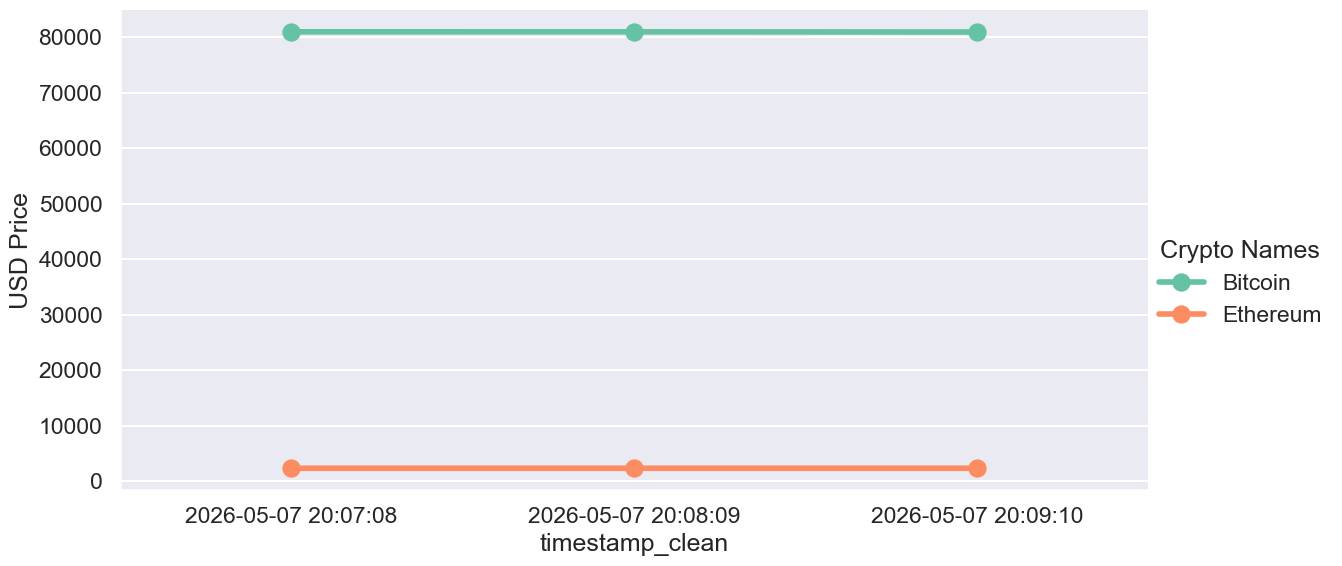

In [254]:
# 修改列名
df12 = df12.rename(columns={'quote.USD.price': 'USD Price', 'names': 'Crypto Names'})

# 第一步：把字符串变成真正的 Datetime 对象（必须先做这一步！）
df12['timestamp'] = pd.to_datetime(df12['timestamp'])

# 第二步：现在你可以安全地使用 .dt 访问器了
df12['timestamp_clean'] = df12['timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

sns.set_style('darkgrid') # 设置 Seaborn 的样式为白色网格
sns.set_palette('Set2') # 设置 Seaborn 的调色板为 Set2，提供一组柔和的颜色
sns.set_context('talk') # 设置 Seaborn 的上下文为 'talk'，以调整图表的字体大小和元素比例，使其适合在演讲或展示中使用
#sns.set_context('notebook') # 设置 Seaborn 的上下文为 'notebook'，以调整图表的字体大小和元素比例，使其适合在 Jupyter Notebook 中使用

sns.catplot(x='timestamp_clean', y='USD Price', hue='Crypto Names', data=df12, kind='point', height=6, aspect=2) # 创建一个分类图（catplot），以展示比特币价格随时间的变化情况
#sns.lineplot(x='timestamp', y='quote.USD.price', data=df12) # 创建一个线图（lineplot），以展示比特币价格随时间的变化情况